# DTLZ1 Results

In [ ]:
import multiprocessing
from functools import partial
from meamt_core import build_toolbox, gen_inicial_tables, run, generate_dtlz1_front_random
from deap import benchmarks

# 1. Parâmetros
K = 5
NPOP = 1000
NGEN = 600
NOBJ = 5 
IND_SIZE = NOBJ + K - 1 
NUM_TABLES = int((1 << NOBJ)) 
MAX_TABLE_SIZE = int(NPOP / NUM_TABLES)
REF_POINT_HV = [1.1]*NOBJ

# 2. Configurando o Toolbox de forma segura para o multiprocessing
# O 'partial' "congela" o argumento obj=NOBJ na função nativa do DEAP
func_dtlz1_segura = partial(benchmarks.dtlz1, obj=NOBJ)
toolbox = build_toolbox(func_dtlz1_segura, IND_SIZE, NPOP, NOBJ)

# =======================================================
# A TRAVA DE SEGURANÇA (OBRIGATÓRIA NO JUPYTER/WINDOWS)
# =======================================================
if __name__ == '__main__':
    # Cria o pool apenas se for o processo principal
    num_cores = multiprocessing.cpu_count() - 1 
    pool = multiprocessing.Pool(processes=num_cores)
    toolbox.register("map", pool.map) 

    # 3. Inicialização
    pop_inicial = toolbox.population()
    
    # Avaliação inicial
    fitnesses = toolbox.map(toolbox.evaluate, pop_inicial)
    for ind, fit in zip(pop_inicial, fitnesses):
        ind.fitness.values = fit

    tabelas = gen_inicial_tables(pop_inicial, NUM_TABLES, MAX_TABLE_SIZE, NOBJ)
    pareto_real = generate_dtlz1_front_random(NOBJ, 1000)
    reset = 40
    print(f"Iniciando evolução usando {num_cores} threads...")

    # 4. Executando o MEAMT
    logbook = run(tabelas, pareto_real, NUM_TABLES, MAX_TABLE_SIZE, NGEN, toolbox, 0.9, 1.0, REF_POINT_HV, NOBJ, reset)

    # Fechando os processos corretamente
    pool.close()
    pool.join()

    print("Evolução concluída!")

Iniciando evolução usando 15 threads...
Evolução concluída!


[1.0, 1.0, 1.0, 1.0, 0.5007210303157166, 0.4996709728701523, 0.5011202840789014, 0.49901712805406284, 0.5006069011216624]
[1.0, 1.0, 1.0, 1.0, 0.5007210303157166, 0.4996709728701523, 0.5011202840789014, 0.49901712805406284, 0.5006069011216624]
[1.0, 1.0, 1.0, 0.0, 0.49909591904770606, 0.5000248296636793, 0.5010777630143232, 0.49986250868091525, 0.6003696803812374]
[1.0, 1.0, 0.0, 0.3810768000582755, 0.5000228882473462, 0.500197983231678, 0.5000005232396402, 0.5002294951116968, 0.5003618214972839]
[1.0, 1.0, 0.0, 0.3810768000582755, 0.5000228882473462, 0.500197983231678, 0.5000005232396402, 0.5002294951116968, 0.5003618214972839]
[0.0, 0.9968167157378828, 0.004357720191204308, 0.2912881220906678, 0.5000006861496359, 0.5000027027065042, 0.4999992866572728, 0.4999959024578786, 0.49999987278157576]
[1.0, 0.0, 0.7792220237206939, 0.08536630134075016, 0.500033488520553, 0.5000123686489479, 0.5000017543756844, 0.49998428230865233, 0.5000116697353666]
[1.0, 1.0, 1.0, 7.578551610276651e-05, 0.5

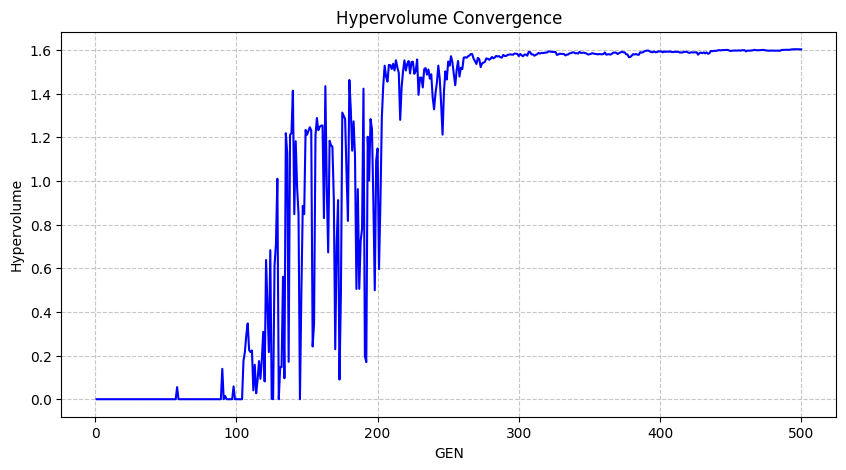

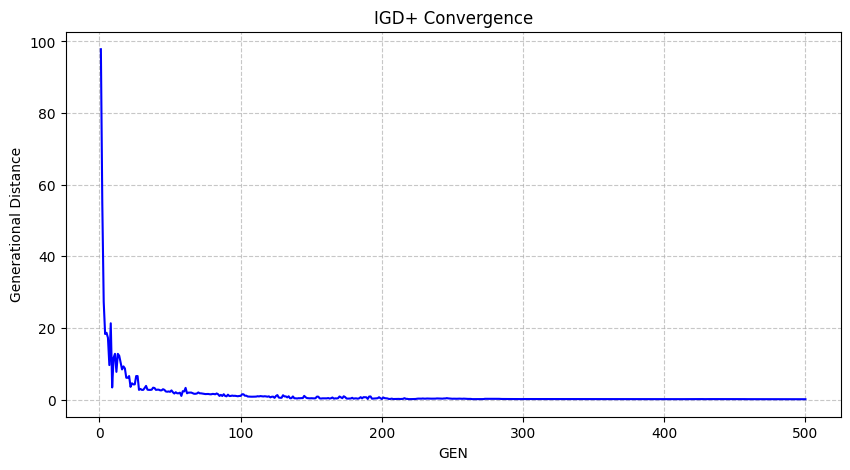

In [4]:
import matplotlib.pyplot as plt
# 3D Graphic of final pareto front
for ind in tabelas[0]:
    print(ind)
# Hypervolume Graphic
gen = logbook.select("gen")
fit_hv = logbook.select("hypervolume")
plt.figure(figsize=(10, 5))
plt.plot(gen, fit_hv, 'b-')
plt.title("Hypervolume Convergence")
plt.xlabel('GEN')
plt.ylabel('Hypervolume')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()
\
# IGD+ Graphic
gen = logbook.select("gen")
fit_igd = logbook.select("igd_plus")
plt.figure(figsize=(10, 5))
plt.plot(gen, fit_igd, 'b-')
plt.title("IGD+ Convergence")
plt.xlabel('GEN')
plt.ylabel('Generational Distance')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()